# 02. KMeans Clustering: Model and Adjustments on Full Signal Features

Loads the baseline claim from the baseline notebook, builds a client grouped split, searches for the best k, fits the final KMeans model, and names each cluster against the rule based baseline. The archetype distribution produced here is the claim after the model is run, revisited in the model validation notebook.

## Setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# the five behavioral features the final KMeans model clusters on, shared by every
# notebook downstream of this fit so the feature set cannot silently drift between the
# clustering, validation, and leakage audit notebooks
FEATURE_COLS = ["ctr", "avg_position", "days_since_last_update", "total_impressions_log", "engagement_rate_filled"]

# the six archetypes a cluster is allowed to match against when named against the rule
# based baseline. monitor is the rule engine's own catch all, not a named archetype, and
# cannibalization_risk is a relational fact about two pages, not a per page pattern a
# cluster can be scored against, so neither belongs in this list
CANDIDATE_ARCHETYPES = [
    "champions", "hidden_gems", "rising_stars", "stale_visible_pages",
    "engagement_problem_pages", "weak_no_demand_pages",
]

# shared by the baseline notebook's rule based action and this notebook's cluster
# naming, so the same archetype always maps to the same action everywhere in the project
ACTION_MAP = {
    "champions": "protect",
    "hidden_gems": "improve",
    "rising_stars": "monitor",
    "stale_visible_pages": "refresh",
    "engagement_problem_pages": "rewrite",
    "weak_no_demand_pages": "prune",
    "cannibalization_risk": "merge",
    "monitor": "monitor",
}


def compute_canonical_relabel(raw_labels, sort_key_values):
    """Compute an {old_id: new_id} mapping that relabels clusters in descending order of
    mean sort_key_values.

    sklearn's KMeans only guarantees the cluster partition is stable for a fixed random
    state, not which integer id each group receives, since that depends on floating point
    reduction order inside the underlying BLAS calls. Relabeling by a meaningful metric,
    descending mean CTR throughout this project, keeps cluster id 0 pointing at the same
    kind of cluster across reruns. Exposed separately from canonicalize_clusters so the
    same mapping, derived once from a train fit, can be applied to a separate test set's
    raw cluster ids from the same fitted model.
    """
    order = pd.Series(sort_key_values).groupby(raw_labels).mean().sort_values(ascending=False).index
    return {old: new for new, old in enumerate(order)}


def canonicalize_clusters(raw_labels, sort_key_values):
    """Relabel cluster ids in descending order of mean sort_key_values.

    Convenience wrapper around compute_canonical_relabel for the common case of computing
    the mapping and applying it to the same array of raw labels.
    """
    relabel = compute_canonical_relabel(raw_labels, sort_key_values)
    return pd.Series(raw_labels).map(relabel).values


page_level = pd.read_csv("../interim/page_level.csv")
print(page_level.shape)

## Step 4: Split train and test grouped by client

Splitting shuffles the list of clients, not the list of pages, and assigns about 20 percent of clients to test, so every page from a given client stays entirely in train or entirely in test. A page level random split would let the same client appear on both sides, and any client level pattern, one client updating content less often, one client having a GA4 tracking quirk, would then leak into both splits and make the model look like it generalizes when it is really just recognizing that client again. The client list is sorted before shuffling so the split stays stable across reruns even though the page level row order is not guaranteed stable, and zero clients ever appear in both train and test, confirmed again in the leakage audit.

In [2]:
feature_cols_raw = ["total_impressions", "total_clicks", "ctr", "avg_position", "days_since_last_update"]

model_data = page_level[page_level["archetype"] != "INSUFFICIENT_DATA"].copy()
model_data = model_data.dropna(subset=feature_cols_raw)
print(f"model_data rows: {len(model_data)}")

os.makedirs("../interim", exist_ok=True)
model_data.to_csv("../interim/model_data.csv", index=False)

# sort before shuffling: page order from a CSV built off a remote parquet read is not
# guaranteed stable, and an unsorted unique() would silently change which clients land
# in train vs test between executions
np.random.seed(42)
all_clients = np.sort(page_level["client_hash_id"].unique())
np.random.shuffle(all_clients)
n_test_clients = max(1, int(len(all_clients) * 0.2))
test_clients = set(all_clients[:n_test_clients])
train_clients = set(all_clients[n_test_clients:])

model_data["split"] = np.where(model_data["client_hash_id"].isin(train_clients), "train", "test")
train = model_data[model_data["split"] == "train"].copy()
test = model_data[model_data["split"] == "test"].copy()
print(f"train rows: {len(train)}, test rows: {len(test)}")

overlap_clients = set(train["client_hash_id"]) & set(test["client_hash_id"])
print(f"clients appearing in both train and test (should be 0): {len(overlap_clients)}")

model_data rows: 122379


train rows: 107523, test rows: 14856
clients appearing in both train and test (should be 0): 0


## Step 5: Log transform impressions, fill engagement, then scale

total_impressions gets a log transform so its long right tail does not dominate distance based clustering, and missing engagement_rate gets filled with 0. A handful of very high traffic pages can dominate a raw distance calculation, collapsing most other pages into one large generic cluster, and the log transform compresses that tail so position, CTR, and staleness can still contribute. engagement_rate is missing specifically when a page had zero GA4 sessions, meaning no engagement could be observed at all, not that engagement was measured poorly, so filling with 0 keeps that as a real value instead of silently dropping the row. train and test each gain a total_impressions_log column and an engagement_rate_filled column.

In [3]:
train["total_impressions_log"] = np.log1p(train["total_impressions"])
test["total_impressions_log"] = np.log1p(test["total_impressions"])

train["engagement_rate_filled"] = train["engagement_rate"].fillna(0)
test["engagement_rate_filled"] = test["engagement_rate"].fillna(0)

## Step 5b: Feature set, scaler, and archetype matching setup

The clustering feature set is fixed here to full_signal, CTR, position, staleness, total_impressions_log, and engagement_rate_filled, the scaler is fixed to RobustScaler, and the list of real archetypes a cluster is allowed to match against gets defined too, used later when clusters get named against the rule based baseline. Four feature sets were tried during exploration. A narrower set using only CTR, position, and staleness reached higher raw statistical separation, but it cannot see the volume and engagement gates several archetypes are partly defined on, so it could never recover engagement_problem_pages or weak_no_demand_pages, while full_signal was the only set that ever recovered all six real archetypes, and RobustScaler beat StandardScaler for it at every k checked. monitor is left out of the candidate list on purpose, since it is the rule engine's own catch all rather than one of the assignment's named archetypes, and cannibalization_risk is left out too, since it is a relational fact about two pages sharing a keyword, not a shape based pattern. FEATURE_COLS and SCALER get fixed here and reused by every step that follows, k itself gets chosen by silhouette in Step 6.

In [4]:
FEATURE_SET_NAME = "full_signal"  # shape from ctr, position, and staleness, plus demand from impressions, plus quality from engagement
SCALER = RobustScaler

MIN_NAMING_CONFIDENCE = 0.35  # about double the roughly 17 percent six equally likely archetypes would clear by chance alone, reported as a confidence flag, not a fallback trigger

SIL_SAMPLE_SIZE = 5000

def fit_full_signal(k_val):
    scl = SCALER()
    Xtr = scl.fit_transform(train[FEATURE_COLS])
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    raw_labels = km.fit_predict(Xtr)
    labels = canonicalize_clusters(raw_labels, train["ctr"].values)
    return labels, Xtr, km

## Exploration: k equal to 7, 15, 20, and 30

full_signal with RobustScaler gets fit directly at four specific values of k here, each scored on silhouette. This is the progression that led to picking k=20 as the explicit final choice, kept visible rather than asserted. Silhouette moves around in a fairly narrow band across these four values, none of them stands out as a clearly better separated clustering than the others.

In [5]:
exploration_results = []
for k_try in [7, 15, 20, 30]:
    labels, Xtr, km = fit_full_signal(k_try)
    sil = silhouette_score(Xtr, labels, sample_size=SIL_SAMPLE_SIZE, random_state=42)
    max_cluster_frac = pd.Series(labels).value_counts(normalize=True).max()
    exploration_results.append({"k": k_try, "silhouette": sil, "max_cluster_frac": max_cluster_frac})

exploration_df = pd.DataFrame(exploration_results).set_index("k")
exploration_df

,silhouette,max_cluster_frac
k,,
7,0.358076,0.286748
15,0.320222,0.163695
20,0.326640,0.157566
30,0.305686,0.105084


## Step 6: Search k for the full signal feature set

Every k from 3 to 30 gets searched here for the fixed full_signal and RobustScaler configuration, scored on the classic elbow measure of inertia and on silhouette. A full search across the whole range shows whether a differently separated clustering was hiding in between the four values spot checked above. The largest cluster's share of rows gets tracked too, so an option that only looks well separated because one giant cluster swallows most of the data can be told apart from a genuinely balanced one.

In [6]:
k_range = range(3, 31)
k_search_results = []

for k_try in k_range:
    km = KMeans(n_clusters=k_try, random_state=42, n_init=10)
    scl = SCALER()
    Xtr = scl.fit_transform(train[FEATURE_COLS])
    labels = km.fit_predict(Xtr)
    sil = silhouette_score(Xtr, labels, sample_size=SIL_SAMPLE_SIZE, random_state=42)
    max_cluster_frac = pd.Series(labels).value_counts(normalize=True).max()
    k_search_results.append({
        "k": k_try, "inertia": km.inertia_, "silhouette": sil,
        "max_cluster_frac": max_cluster_frac,
    })

k_search_df = pd.DataFrame(k_search_results)
k_search_df

,k,inertia,silhouette,max_cluster_frac
0,3,370643.482840,0.557521,0.819583
1,4,289833.069024,0.355196,0.452443
2,5,231293.850452,0.359331,0.420143
3,6,199389.323407,0.346618,0.336849
4,7,172722.795091,0.358076,0.286748
5,8,153170.819385,0.359932,0.284404
6,9,140522.044699,0.333000,0.284758
7,10,126729.088042,0.342140,0.244311
8,11,118229.142245,0.347991,0.209016
9,12,110402.248180,0.346755,0.206356


## Step 6b: Pick k

The highest silhouette among balanced configurations, largest cluster under 45 percent of rows, gets compared here against an explicit choice of k=20, and k=20 is what the rest of the notebook uses. Silhouette moves in a fairly narrow band across most of this range rather than pointing sharply at one value, so k=20 sits well within the normal range for this search rather than trading away much separation for the explicit choice. The silhouette optimal row is still printed for reference so that comparison stays visible rather than hidden.

In [7]:
auto_best_k_row = k_search_df[k_search_df["max_cluster_frac"] <= 0.45].sort_values("silhouette", ascending=False).iloc[0]
print("silhouette optimal pick among balanced options, for reference, not used as the final model:")
print(auto_best_k_row)
print()

k = 20  # explicit choice, see markdown above
chosen_k_row = k_search_df[k_search_df["k"] == k].iloc[0]
print(f"using k {k}, explicit choice:")
print(chosen_k_row)

silhouette optimal pick among balanced options, for reference, not used as the final model:
k                        8.000000
inertia             153170.819385
silhouette               0.359932
max_cluster_frac         0.284404
Name: 5, dtype: float64

using k 20, explicit choice:
k                      20.000000
inertia             71034.583523
silhouette              0.326640
max_cluster_frac        0.157566
Name: 17, dtype: float64


## Step 6c: Elbow and silhouette against k

Inertia and silhouette both get plotted against k here, with a line marking the chosen k=20. Neither shows one clear break point, inertia falls smoothly as k grows the way it always does, and silhouette moves in a narrow band across most of the range, which is part of why the explicit choice of k=20 needed a stated reason rather than an automatic pick.

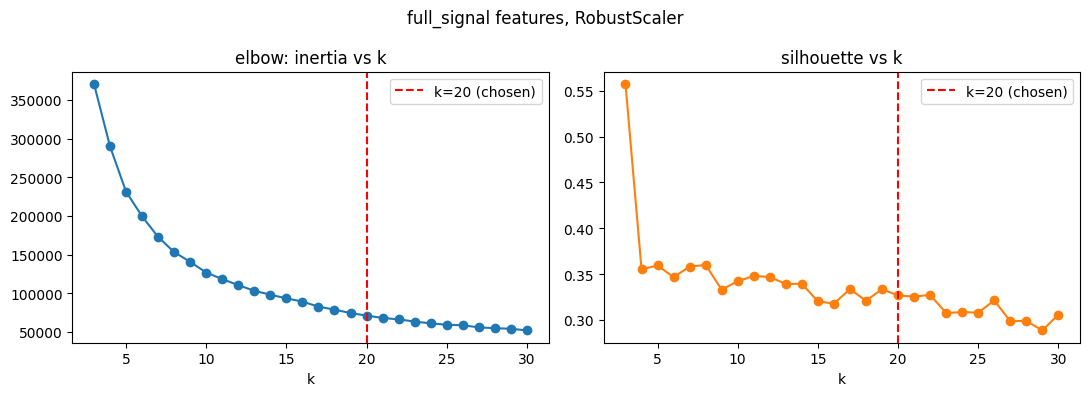

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(k_search_df["k"], k_search_df["inertia"], marker="o")
axes[0].set_title("elbow: inertia vs k")
axes[0].set_xlabel("k")

axes[1].plot(k_search_df["k"], k_search_df["silhouette"], marker="o", color="tab:orange")
axes[1].set_title("silhouette vs k")
axes[1].set_xlabel("k")

for ax in axes:
    ax.axvline(x=k, color="red", linestyle="--", label=f"k={k} (chosen)")
    ax.legend()

plt.suptitle(f"{FEATURE_SET_NAME} features, RobustScaler")
plt.tight_layout()
plt.show()

## Step 7: Fit the final KMeans model with the chosen k

KMeans gets fit here with full_signal features, RobustScaler, and k=20 on train, then the raw cluster ids get relabeled in order of descending mean CTR so cluster 0 always means the best CTR cluster no matter how sklearn happened to number them internally on a given run. sklearn's KMeans only guarantees the partition itself is reproducible for a fixed random state, which integer id each group receives can still change between runs because of floating point reduction order inside the underlying BLAS calls, so fixing the id order to something meaningful keeps every later step, the naming especially, valid across reruns instead of silently pointing at the wrong group. train and test both come out with a stable kmeans_cluster column, and their silhouette scores are printed for a first look at separation quality.

In [9]:
scaler = SCALER()
X_train = scaler.fit_transform(train[FEATURE_COLS])
X_test = scaler.transform(test[FEATURE_COLS])

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
raw_train_clusters = kmeans.fit_predict(X_train)
raw_test_clusters = kmeans.predict(X_test)

relabel = compute_canonical_relabel(raw_train_clusters, train["ctr"].values)
train_clusters = pd.Series(raw_train_clusters).map(relabel).values
test_clusters = pd.Series(raw_test_clusters).map(relabel).values

train["kmeans_cluster"] = train_clusters
test["kmeans_cluster"] = test_clusters

train_silhouette = silhouette_score(X_train, train_clusters, sample_size=SIL_SAMPLE_SIZE, random_state=42)
test_silhouette = silhouette_score(X_test, test_clusters, sample_size=SIL_SAMPLE_SIZE, random_state=42)

print(f"{FEATURE_SET_NAME} features, k={k}")
print(f"train silhouette: {train_silhouette:.3f}")
print(f"test silhouette: {test_silhouette:.3f}")
print("\ncluster sizes (train):")
print(train["kmeans_cluster"].value_counts().sort_index())

full_signal features, k=20
train silhouette: 0.327
test silhouette: 0.302

cluster sizes (train):
kmeans_cluster
0        22
1        66
2       419
3       746
4      1474
5      1490
6      4218
7      5534
8      8181
9      5865
10    11536
11    11870
12      291
13    10175
14     7477
15     3683
16     8010
17     3229
18    16942
19     6295
Name: count, dtype: int64


## Step 8: PCA projection for visualization

The scaled clustering features get projected down to two dimensions here with PCA, and every training page gets plotted, colored by its cluster. The clustering itself happens in five dimensions, which cannot be looked at directly, so a two dimensional projection is a rough but useful way to see whether the clusters look like separated groups or one continuous blob. The plot reports how much variance each of the two plotted components explains, and shows the twenty clusters as differently colored regions in that projection.

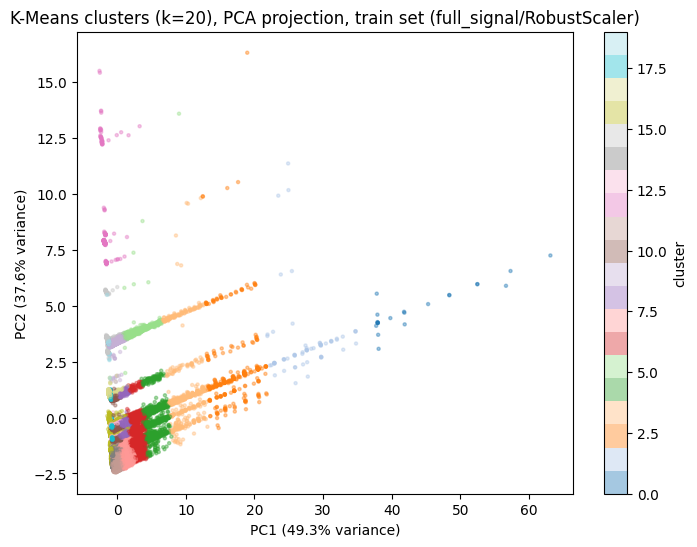

In [10]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters, cmap="tab20", alpha=0.4, s=5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"K-Means clusters (k={k}), PCA projection, train set ({FEATURE_SET_NAME}/RobustScaler)")
plt.colorbar(scatter, label="cluster")
plt.show()

## Step 9: Cluster profiling, the real numbers behind each cluster

train gets grouped by kmeans_cluster here and the average of every real, non log metric gets reported for each one, impressions, clicks, CTR, position, days since update, and engagement rate. This table has to get read before any cluster gets a name, naming clusters before looking at what is actually inside them is the exact mistake this assignment warns against. cluster_profile ends up holding one row per cluster with its size and its average metrics, used directly by the validation and naming steps that follow.

In [11]:
profile_cols = ["total_impressions", "total_clicks", "ctr", "avg_position", "days_since_last_update", "engagement_rate"]

cluster_profile = train.groupby("kmeans_cluster").agg(
    n=("content_hash_id", "count"),
    **{f"avg_{c}": (c, "mean") for c in profile_cols}
).reset_index()

cluster_profile

,kmeans_cluster,n,avg_total_impressions,avg_total_clicks,avg_ctr,avg_avg_position,avg_days_since_last_update,avg_engagement_rate
0,0,22,46.954545,8.954545,0.210330,5.105771,39.863636,0.043753
1,1,66,24.045455,3.181818,0.131987,9.442979,50.257576,0.082292
2,2,419,23.563246,1.887828,0.081637,14.739755,49.431981,0.052389
3,3,746,81.537534,3.765416,0.049347,15.293607,51.060322,0.053782
4,4,1474,303.989145,8.269335,0.028719,15.546308,35.551560,0.046358
5,5,1490,335.912081,5.159732,0.016553,16.770917,125.322819,0.040246
6,6,4218,762.897345,12.333570,0.015655,13.885474,32.617117,0.051303
7,7,5534,2721.661005,23.337008,0.007966,13.556736,12.097940,0.043006
8,8,8181,829.457524,6.762865,0.007709,12.724718,39.100232,0.041680
9,9,5865,2112.024211,6.235124,0.004458,15.524440,124.934868,0.036024


## Step 9b: Check each cluster's identity against the rule based baseline

kmeans_cluster gets cross tabulated here against the rule based archetype column, row normalized, and the plurality vote among the six real archetypes becomes each cluster's best matching archetype, with the vote share becoming that cluster's naming confidence score. Eyeballing cluster_profile is not enough to justify a name, this is the actual check behind the names used next. Not every one of the six archetypes needs to show up and more than one cluster is allowed to share the same archetype, the only claim being made is that a given cluster's plurality vote among the rule based labels is a specific archetype. validation ends up holding each cluster's size, its best matching archetype, and its naming confidence percentage.

In [12]:
rule_composition = pd.crosstab(train["kmeans_cluster"], train["archetype"], normalize="index")
rule_composition_candidates = rule_composition[[c for c in CANDIDATE_ARCHETYPES if c in rule_composition.columns]]

best_fit = rule_composition_candidates.idxmax(axis=1)
naming_confidence = rule_composition_candidates.max(axis=1)

validation = pd.DataFrame({
    "n": train["kmeans_cluster"].value_counts().sort_index(),
    "best_fit_archetype": best_fit,
    "naming_confidence_pct": (naming_confidence * 100).round(1),
})
validation

,n,best_fit_archetype,naming_confidence_pct
kmeans_cluster,,,
0,22,hidden_gems,86.4
1,66,hidden_gems,81.8
2,419,hidden_gems,57.3
3,746,hidden_gems,48.1
4,1474,rising_stars,44.8
5,1490,rising_stars,66.7
6,4218,rising_stars,47.3
7,5534,rising_stars,55.9
8,8181,champions,49.3


## Step 10: Name each cluster and map it to an action, the claim after the model runs

The best matching archetype gets read straight from validation for every cluster whose naming confidence clears 35 percent, and clusters below that bar get labeled needs_review instead, given monitor as their action. Names come from the data, not a hand typed guess, and a weak plurality vote should not be forced to claim a specific archetype it barely matches. archetype_kmeans is the model's claim after running KMeans, compared against the rule based claim from the baseline notebook in the model validation notebook.

In [13]:
NEEDS_REVIEW_LABEL = "needs_review"

cluster_archetype_map = {}
for cid in sorted(train["kmeans_cluster"].unique()):
    name, conf = best_fit[cid], naming_confidence[cid]
    if conf < MIN_NAMING_CONFIDENCE:
        cluster_archetype_map[cid] = (NEEDS_REVIEW_LABEL, "monitor")
    else:
        cluster_archetype_map[cid] = (name, ACTION_MAP[name])

train["archetype_kmeans"] = train["kmeans_cluster"].map(lambda c: cluster_archetype_map[c][0])
train["recommended_action"] = train["kmeans_cluster"].map(lambda c: cluster_archetype_map[c][1])

test["archetype_kmeans"] = test["kmeans_cluster"].map(lambda c: cluster_archetype_map[c][0])
test["recommended_action"] = test["kmeans_cluster"].map(lambda c: cluster_archetype_map[c][1])

train["recommended_action"] = np.where(train["cannibalization_risk"], "merge", train["recommended_action"])
test["recommended_action"] = np.where(test["cannibalization_risk"], "merge", test["recommended_action"])

print("claim after, the model's archetype distribution:")
print(train["archetype_kmeans"].value_counts())
print()
print(train["recommended_action"].value_counts())

claim after, the model's archetype distribution:
archetype_kmeans
needs_review                47510
weak_no_demand_pages        20462
rising_stars                18581
engagement_problem_pages    11536
champions                    8181
hidden_gems                  1253
Name: count, dtype: int64

recommended_action
monitor    66090
prune      20462
rewrite    11535
protect     8181
improve     1253
merge          2
Name: count, dtype: int64


## Step 10b: The final archetype table, cluster profiles, names, and actions

cluster_profile gets joined here with the archetype name, naming confidence, and confidence flag from the validation and naming steps, and with the recommended action, into a single table. This is the assignment's required output in one place, real numbers, a name, and an action, instead of spread across three separate tables a reader has to cross reference by hand. best_archetype_table ends up holding one row per cluster, sorted by naming confidence, ready to hand to a person deciding what to do with each group of pages.

In [14]:
best_archetype_table = cluster_profile.set_index("kmeans_cluster").copy()
best_archetype_table["archetype"] = best_archetype_table.index.map(lambda c: cluster_archetype_map[c][0])
best_archetype_table["naming_confidence_pct"] = validation["naming_confidence_pct"]
best_archetype_table["confident"] = best_archetype_table["naming_confidence_pct"] >= MIN_NAMING_CONFIDENCE * 100
best_archetype_table["action"] = best_archetype_table.index.map(lambda c: cluster_archetype_map[c][1])

best_archetype_table = best_archetype_table.sort_values("naming_confidence_pct", ascending=False)
best_archetype_table

,n,avg_total_impressions,avg_total_clicks,avg_ctr,avg_avg_position,avg_days_since_last_update,avg_engagement_rate,archetype,naming_confidence_pct,confident,action
kmeans_cluster,,,,,,,,,,,
0,22,46.954545,8.954545,0.210330,5.105771,39.863636,0.043753,hidden_gems,86.4,True,improve
1,66,24.045455,3.181818,0.131987,9.442979,50.257576,0.082292,hidden_gems,81.8,True,improve
5,1490,335.912081,5.159732,0.016553,16.770917,125.322819,0.040246,rising_stars,66.7,True,monitor
2,419,23.563246,1.887828,0.081637,14.739755,49.431981,0.052389,hidden_gems,57.3,True,improve
7,5534,2721.661005,23.337008,0.007966,13.556736,12.097940,0.043006,rising_stars,55.9,True,monitor
8,8181,829.457524,6.762865,0.007709,12.724718,39.100232,0.041680,champions,49.3,True,protect
3,746,81.537534,3.765416,0.049347,15.293607,51.060322,0.053782,hidden_gems,48.1,True,improve
6,4218,762.897345,12.333570,0.015655,13.885474,32.617117,0.051303,rising_stars,47.3,True,monitor
4,1474,303.989145,8.269335,0.028719,15.546308,35.551560,0.046358,rising_stars,44.8,True,monitor


## Save output

train and test get written here, with cluster id, archetype, action, and the derived feature columns, plus the final archetype table. The model validation, leakage audit, and split comparison notebooks load these directly instead of refitting the model. work/interim/train.csv, test.csv, and best_archetype_table.csv get written.

In [15]:
output_cols = [
    "client_hash_id", "content_hash_id", "kmeans_cluster", "archetype_kmeans",
    "recommended_action", "archetype", "total_impressions", "total_clicks", "ctr",
    "avg_position", "days_since_last_update", "engagement_rate", "total_impressions_log",
    "engagement_rate_filled", "cannibalization_risk",
]

os.makedirs("../interim", exist_ok=True)
train[output_cols].to_csv("../interim/train.csv", index=False)
test[output_cols].to_csv("../interim/test.csv", index=False)
best_archetype_table.to_csv("../interim/best_archetype_table.csv")

print(f"wrote {len(train)} train rows and {len(test)} test rows")

wrote 107523 train rows and 14856 test rows
